# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name: ANDREA YAN



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [1]:
## Import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

import joblib

# 1. Business Understanding
Goal: ?

# 2. Data Understanding

## 2.1 Load dataset

In [2]:
## Read *.csv file into pandas DataFrame
df = pd.read_csv("heart.csv")

df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## 2.2 Summary Statistics

In [3]:
## Understand the type of variable for each column
print(df.shape)

df.info()

df.describe()

df.head()

df.tail()

(918, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1
917,38,M,NAP,138,175,0,Normal,173,N,0.0,Up,0


In [4]:
## Check for missing data
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [5]:
## Describe data distribution
df.duplicated().sum()


np.int64(0)

In [6]:
df = df.drop_duplicates()  

## 2.3 Data Visualization

## 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

C:\Users\kaien\AppData\Local\Temp\ipykernel_7864\2816667734.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='HeartDisease', palette='Set2')


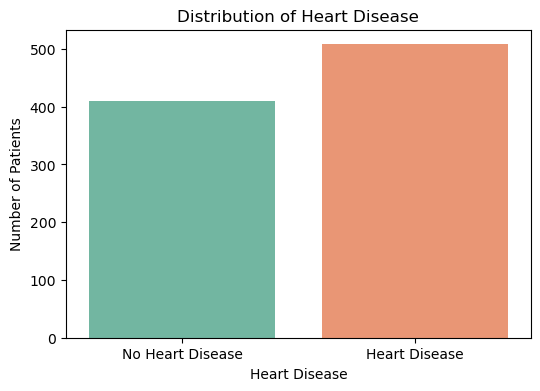

HeartDisease
1    508
0    410
Name: count, dtype: int64
HeartDisease
1    55.337691
0    44.662309
Name: proportion, dtype: float64


In [7]:
## Understanding distribution of target

## Understanding distribution of target

plt.figure(figsize=(6,4))

sns.countplot(data=df, x='HeartDisease', palette='Set2')

plt.title("Distribution of Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")

plt.xticks([0,1], ["No Heart Disease", "Heart Disease"])

plt.show()

print(df['HeartDisease'].value_counts())
print(df['HeartDisease'].value_counts(normalize=True)*100)

### 2.3.1.2 Understanding distribution of features

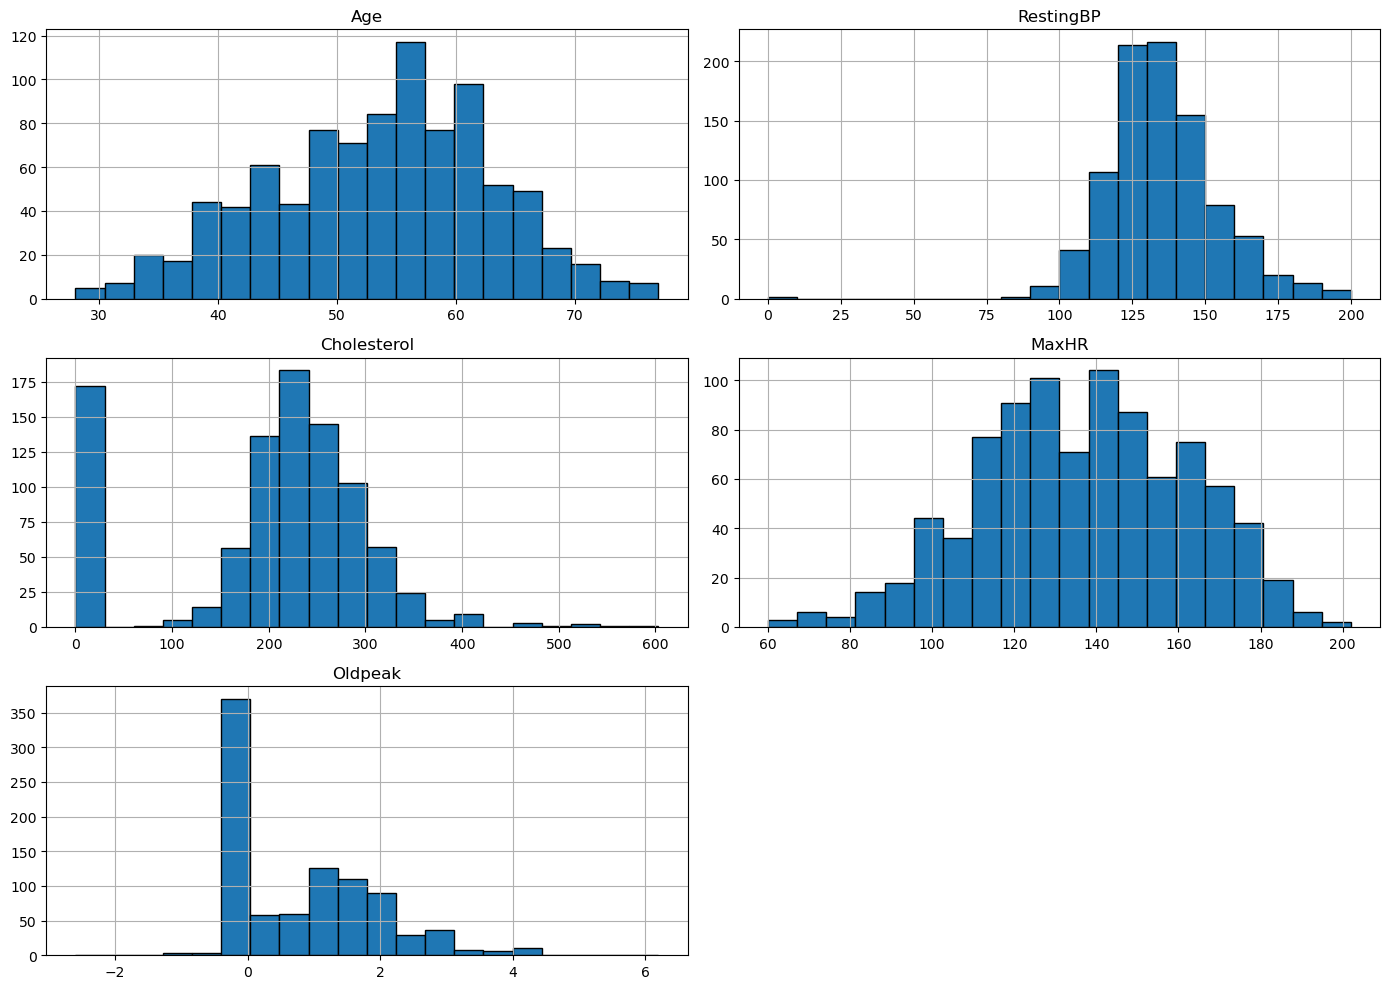

In [8]:
## Understanding distribution of features

numerical_features = [
    'Age',
    'RestingBP',
    'Cholesterol',
    'MaxHR',
    'Oldpeak'
]

df[numerical_features].hist(
    figsize=(14,10),
    bins=20,
    edgecolor='black'
)

plt.tight_layout()
plt.show()


C:\Users\kaien\AppData\Local\Temp\ipykernel_7864\2372575730.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=feature, palette='Set3')


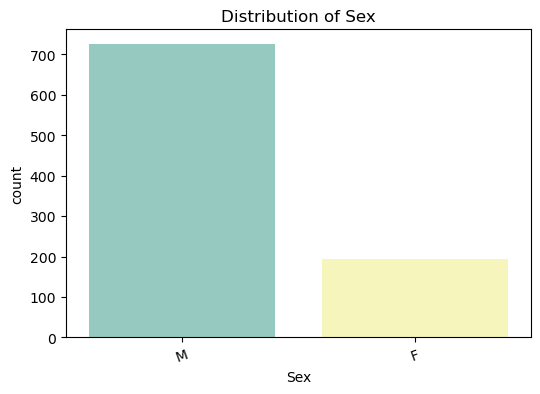

C:\Users\kaien\AppData\Local\Temp\ipykernel_7864\2372575730.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=feature, palette='Set3')


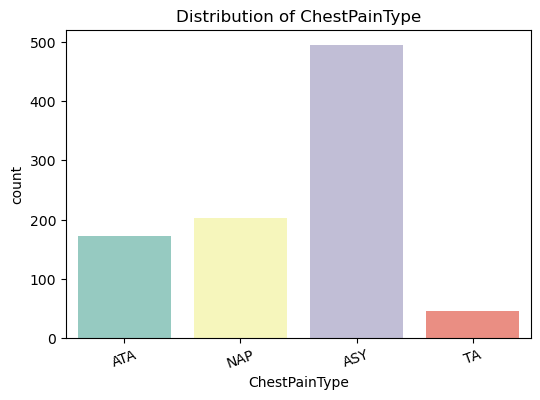

C:\Users\kaien\AppData\Local\Temp\ipykernel_7864\2372575730.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=feature, palette='Set3')


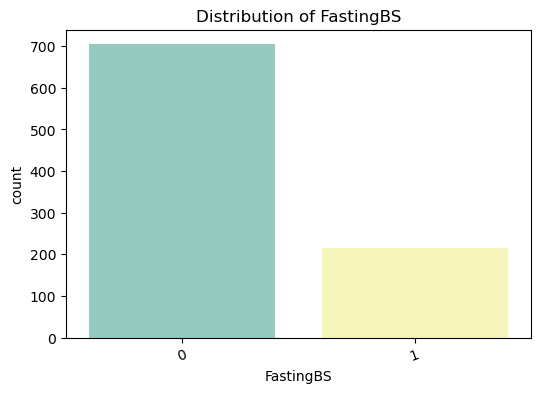

C:\Users\kaien\AppData\Local\Temp\ipykernel_7864\2372575730.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=feature, palette='Set3')


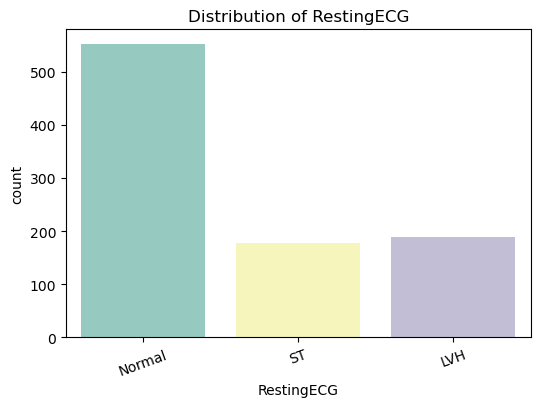

C:\Users\kaien\AppData\Local\Temp\ipykernel_7864\2372575730.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=feature, palette='Set3')


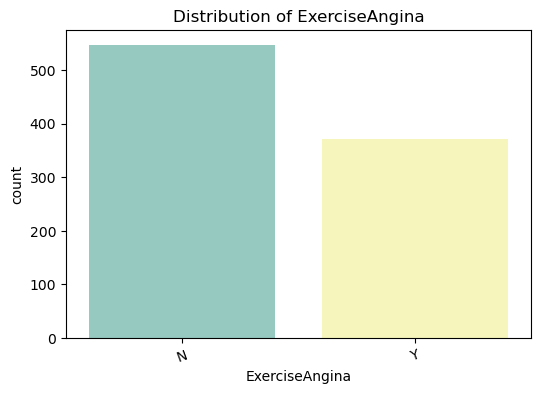

C:\Users\kaien\AppData\Local\Temp\ipykernel_7864\2372575730.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=feature, palette='Set3')


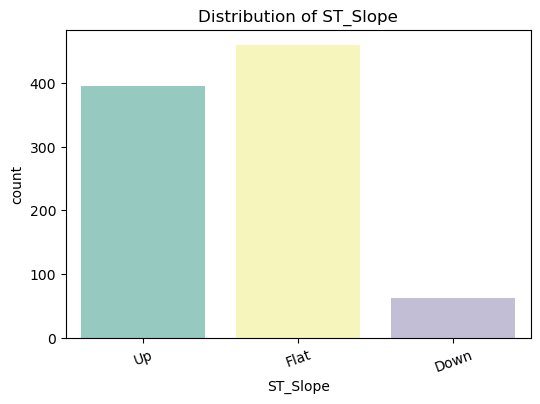

In [9]:
categorical_features = [
    'Sex',
    'ChestPainType',
    'FastingBS',
    'RestingECG',
    'ExerciseAngina',
    'ST_Slope'
]

for feature in categorical_features:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=feature, palette='Set3')

    plt.title(f"Distribution of {feature}")

    plt.xticks(rotation=20)

    plt.show()

In [10]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


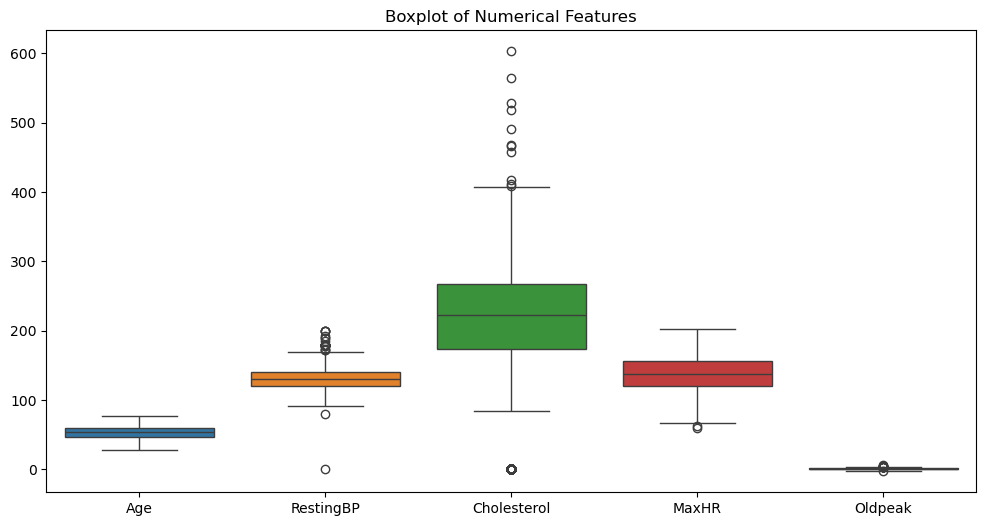

In [11]:
##outliers

plt.figure(figsize=(12,6))

sns.boxplot(data=df[numerical_features])

plt.title("Boxplot of Numerical Features")

plt.show()

### 2.3.2 Understanding relationship between variables

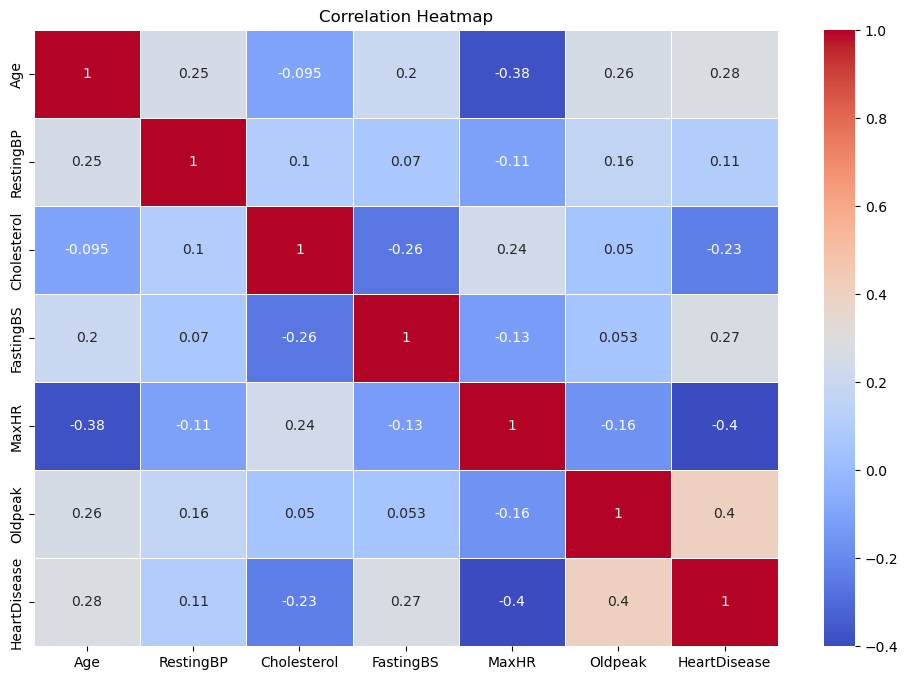

In [12]:
## Understanding relationship between variables

## Understanding relationship between variables

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

# 3. Data Preparation

## 3.1 Data Cleaning

In [13]:
## Clean data

## Check missing values

print("Missing Values")
print(df.isnull().sum())

print("\n")

## Check duplicate values

print("Duplicate Rows:", df.duplicated().sum())

## Remove duplicates

df = df.drop_duplicates()

print("Dataset Shape:", df.shape)

## Encode categorical features using one-hot encoding

categorical_columns = [
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]

df_encoded = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

print("Original dataset shape:", df.shape)
print("Encoded dataset shape:", df_encoded.shape)

df_encoded.head()

Missing Values
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


Duplicate Rows: 0
Dataset Shape: (918, 12)
Original dataset shape: (918, 12)
Encoded dataset shape: (918, 16)


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,0,True,False,True,False,True,False,False,False,True


## 3.2 Train-Test Split

In [14]:
## Split encoded data into training and testing sets

from sklearn.model_selection import train_test_split

X = df_encoded.drop("HeartDisease", axis=1)
y = df_encoded["HeartDisease"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Features Shape: (918, 15)
Target Shape: (918,)

Training Set: (734, 15)
Testing Set: (184, 15)


# 4. Modelling

### 4.2 Train Model

In [15]:
## Initialise and train model

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression
logistic = LogisticRegression(max_iter=1000, random_state=42)
logistic.fit(X_train, y_train)

# Decision Tree
decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train, y_train)

# Random Forest
random_forest = RandomForestClassifier(random_state=42)
random_forest.fit(X_train, y_train)

print("All models trained successfully.")

All models trained successfully.


c:\Users\kaien\anaconda3\envs\mldp\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# 5. Model Evaluation

In [16]:
## Evaluate model

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

models = {
    "Logistic Regression": logistic,
    "Decision Tree": decision_tree,
    "Random Forest": random_forest
}

results = []

for name, model in models.items():

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, accuracy, precision, recall, f1])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.885870,0.871560,0.931373,0.900474
1,Decision Tree,0.782609,0.781818,0.843137,0.811321
2,Random Forest,0.875000,0.883495,0.892157,0.887805


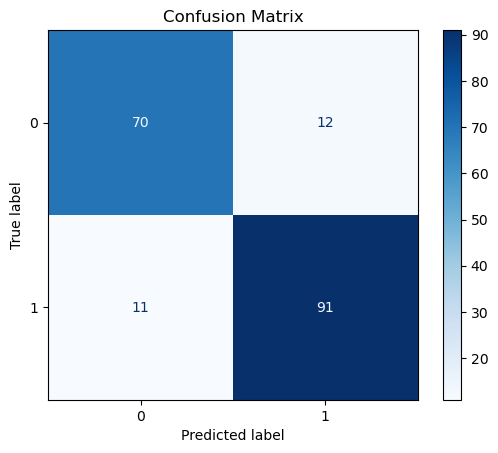

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    random_forest,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

In [18]:
from sklearn.metrics import classification_report

prediction = random_forest.predict(X_test)

print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.86      0.85      0.86        82
           1       0.88      0.89      0.89       102

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.88      0.87       184



In [19]:
## New data

## Predict

# Select one sample from the test set

new_patient = X_test.iloc[[0]]

prediction = random_forest.predict(new_patient)

probability = random_forest.predict_proba(new_patient)

print("Prediction:", prediction[0])
print("Probability:", probability)

Prediction: 1
Probability: [[0.04 0.96]]


## Iterative model development


              Feature  Importance
14        ST_Slope_Up    0.163153
4               MaxHR    0.119229
13      ST_Slope_Flat    0.113410
2         Cholesterol    0.107431
5             Oldpeak    0.099216
12   ExerciseAngina_Y    0.086208
0                 Age    0.079529
1           RestingBP    0.071384
7   ChestPainType_ATA    0.036362
6               Sex_M    0.033044
8   ChestPainType_NAP    0.028466
3           FastingBS    0.026823
10  RestingECG_Normal    0.016400
9    ChestPainType_TA    0.009924
11      RestingECG_ST    0.009422


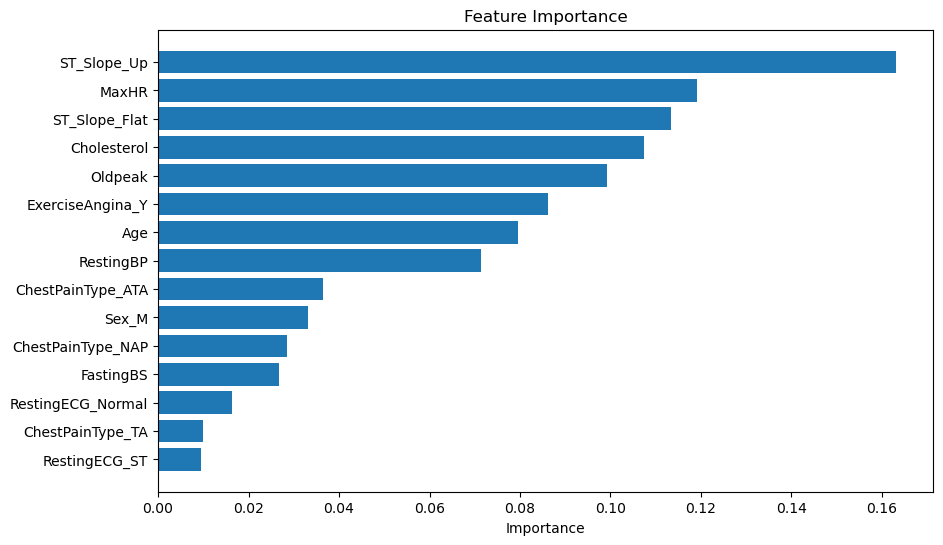

In [20]:
## Further feature engineering / feature selection

## Feature Importance using Random Forest

import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance")
plt.xlabel("Importance")
plt.gca().invert_yaxis()

plt.show()

In [21]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5, 10]
}

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    scoring="accuracy",
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Accuracy:")
print(random_search.best_score_)

Best Parameters:
{'n_estimators': 200, 'min_samples_split': 5, 'max_depth': 10}

Best Accuracy:
0.8664336967663779


In [22]:
best_model = random_search.best_estimator_

prediction = best_model.predict(X_test)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, prediction)

print("Final Test Accuracy:", accuracy)

Final Test Accuracy: 0.8804347826086957


In [23]:
comparison = pd.DataFrame({
    "Model": [
        "Random Forest (Before Tuning)",
        "Random Forest (After Tuning)"
    ],
    "Accuracy": [
        accuracy_score(y_test, random_forest.predict(X_test)),
        accuracy_score(y_test, best_model.predict(X_test))
    ]
})

comparison

,Model,Accuracy
0,Random Forest (Before Tuning),0.875000
1,Random Forest (After Tuning),0.880435


In [24]:
import joblib

# Save the tuned model
joblib.dump(best_model, "heart_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [25]:
feature_names = X_train.columns.tolist()

joblib.dump(feature_names, "feature_names.pkl")

print("Feature names saved successfully!")

Feature names saved successfully!
